# Inferencia estadística vs Aprendizaje de máquinas

### Parte 1: Ajuste de recta 

(Adaptado de  Viviana Acquaviva (2023))

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
#parámetros para generar figuras de alta calidad
font = {'size'   : 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

Generaremos datos que sigan una relación lineal (con ruido) y usaremos una grilla para encontrar el mejor ajuste, sin y con considerar incertezas

In [3]:
np.random.seed(16) #semilla fija para reproducibilidad

x = np.arange(10) 

y = 2*x + 5 + np.random.randn(10) #generamos datos con scatter gausiano

Podemos considerar que los datos corresponden al movimiento de un auto con rapidez constante, donde $x$ es tiempo (en segundos) e $y$ es distancia (en metros)

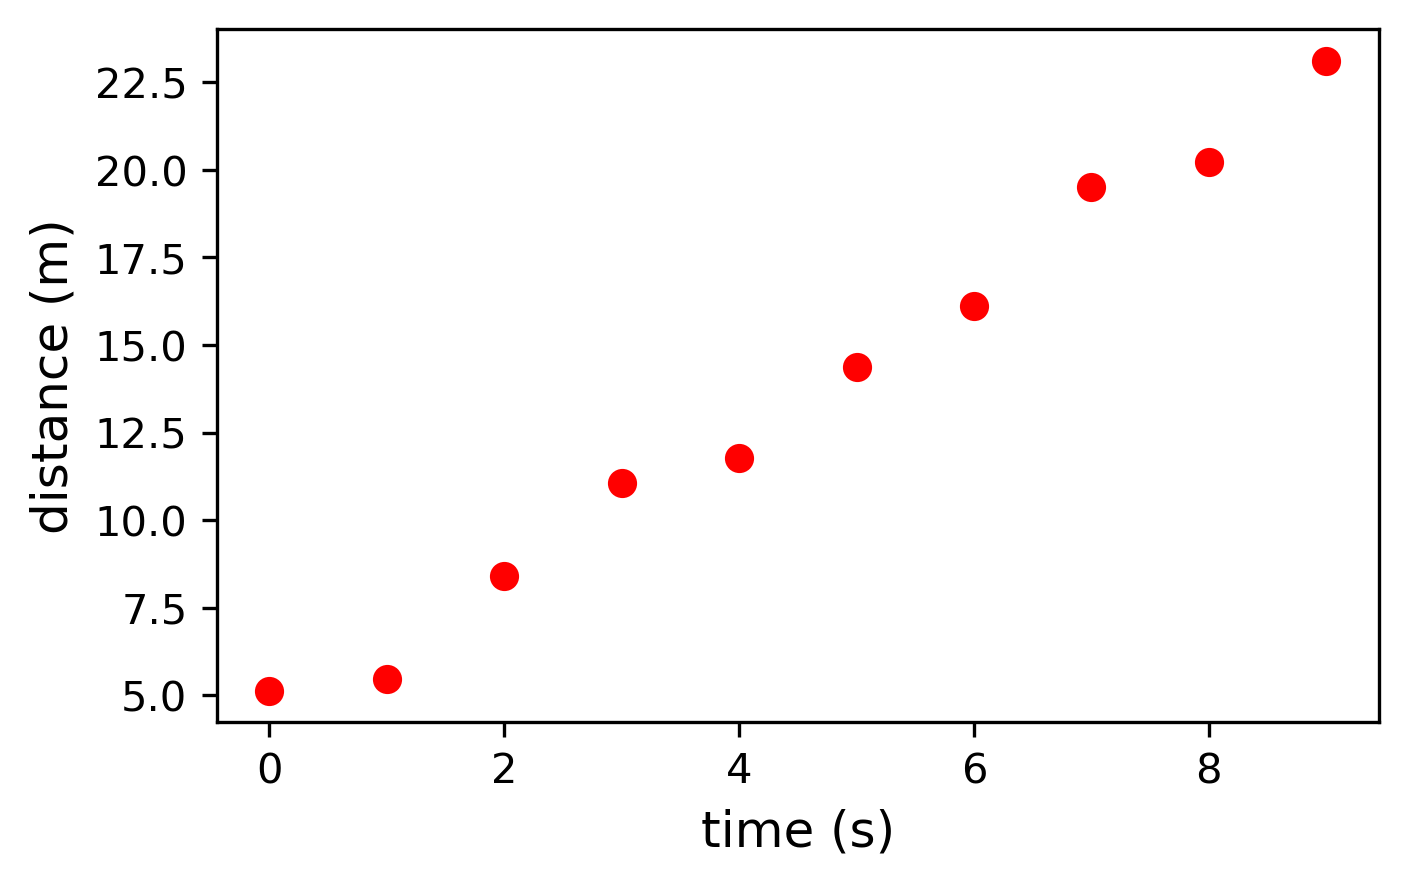

In [4]:
plt.figure(figsize=(5,3)) #
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [5]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
y = np.round(y,1) #redondeamos los datos

In [7]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

Suponga que a partir de esos datos debe ser capaz de decir la distancia a la que estará el auto cuando $t=12$ s. ¿Cómo podemos resolver el problema?

### Inferencia

Ya sabemos que la relación entre distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Este modelo tienen dos parámetros: $d_0$ u $v$. Necesitamos encontrar estos parámetros para poder usar el modelo y determinar $d(t=12 s)$.


¿Cómo haría esto?




Explique con palabras: Para estimar los parámetros del modelo, podemos aplicar el método de mínimos cuadrados sobre las variables $x$ tiempo e $y$ distancia. Con esto obtenemos la recta que mejor se ajusta a las mediciones. Luego, reemplazamos $t = 12$ en la ecuación del modelo ajustado para predecir la distancia del auto a los 12 segundos.

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Encuentre los parámetros de la mejor recta para los datos dados

In [10]:
v, d0 = np.polyfit(x, y, 1)

t_pred = 12
d_pred = d0 + v * t_pred

print(f"Velocidad (v): {v:.3f}")
print(f"Distancia inicial (d0): {d0:.3f}")
print(f"Distancia estimada a los t = 12s: {d_pred:.3f}")

Velocidad (v): 2.048
Distancia inicial (d0): 4.302
Distancia estimada a los t = 12s: 28.884


**Cuáles son los valores de pendiente m e intercepto b encontrado? Con este modelo, cuánto es $d(t=12s)$?**

- **bestm**: 2.048 [m/s]
- **bestb**: 4.302 [m]

In [16]:
bestm = 2.048
bestb = 4.302 
#Con este modelo d(t = 12s) es 28.884 [m]

Graficamos el mejor ajuste con los datos

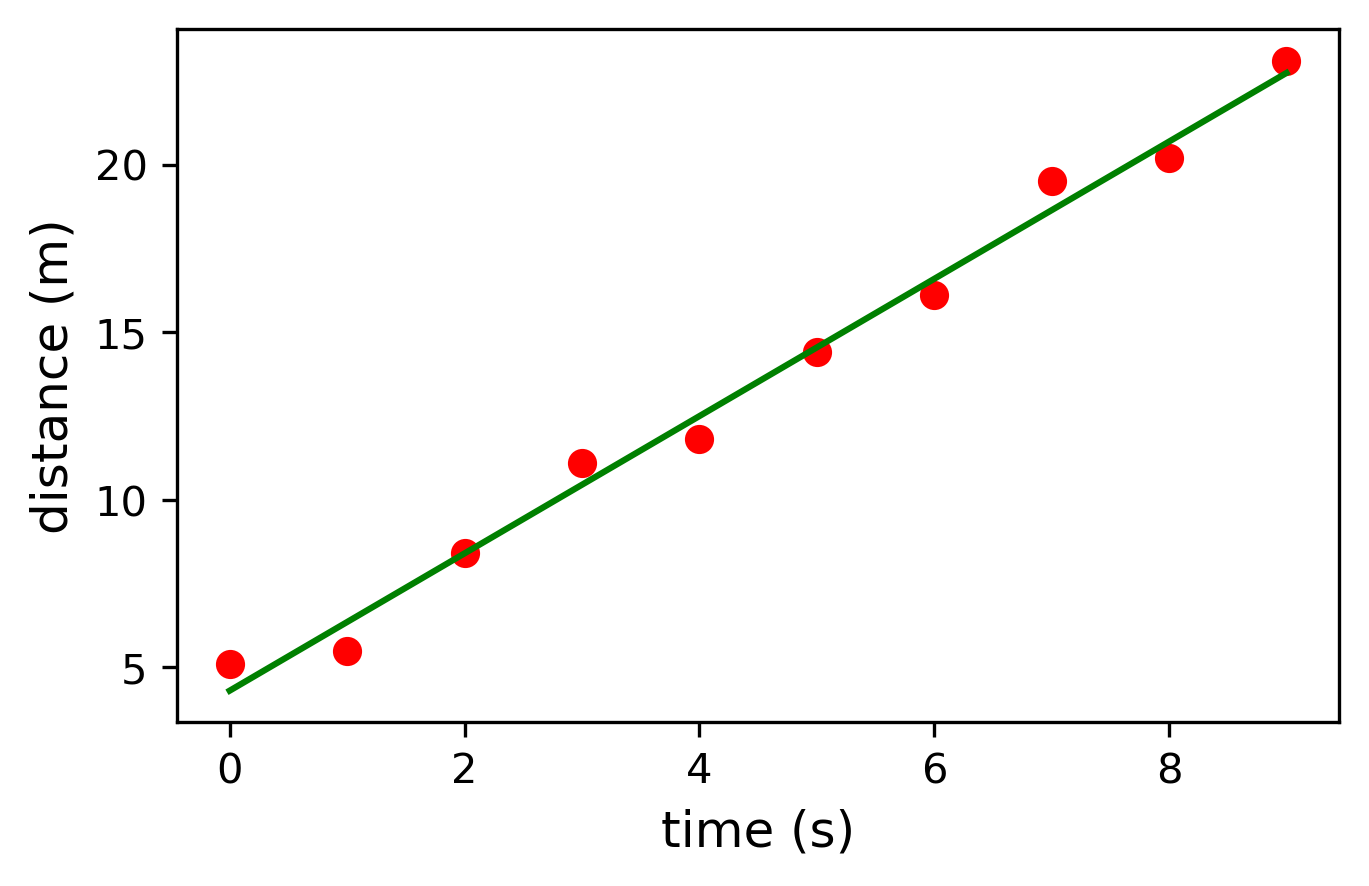

In [17]:
plt.figure(figsize=(5,3))
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'g'); #grafique la recta con los mejores parámetros

Y si agregamos incerteza en la medición de distancias?

In [18]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [19]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

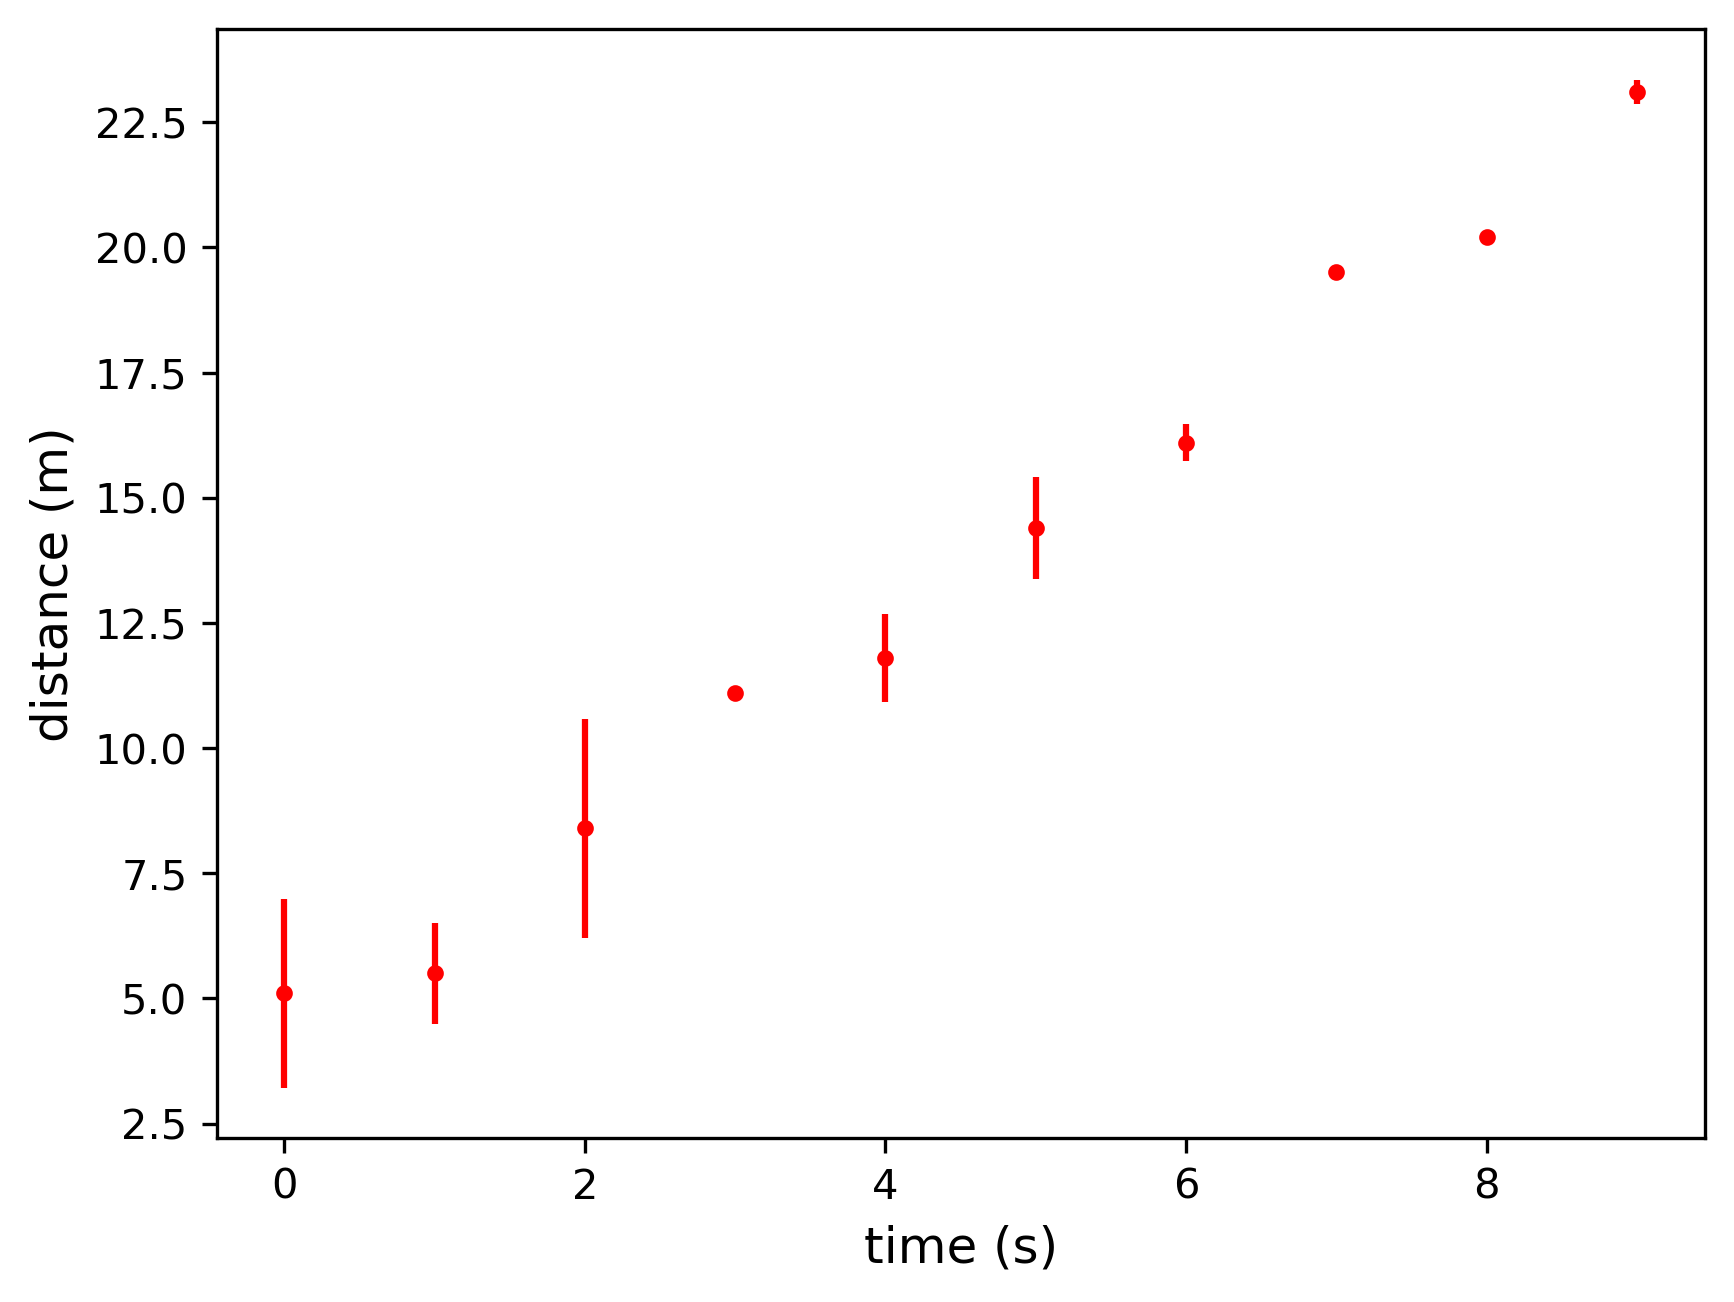

In [20]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Encuentre los parámetros de la mejor recta cuando agregamos incertezas

In [22]:
weights = 1 / np.abs(dy)

(v, d0), cov = np.polyfit(x, y, 1, w=weights, cov=True)

print(f"bestm_werr: {v:.3f}")
print(f"bestb_werr: {d0:.3f}")

bestm_werr: 1.820
bestb_werr: 5.639


In [23]:
bestm_werr = 1.820
bestb_werr = 5.639

Graficamos los datos con incertezas y el nuevo ajuste

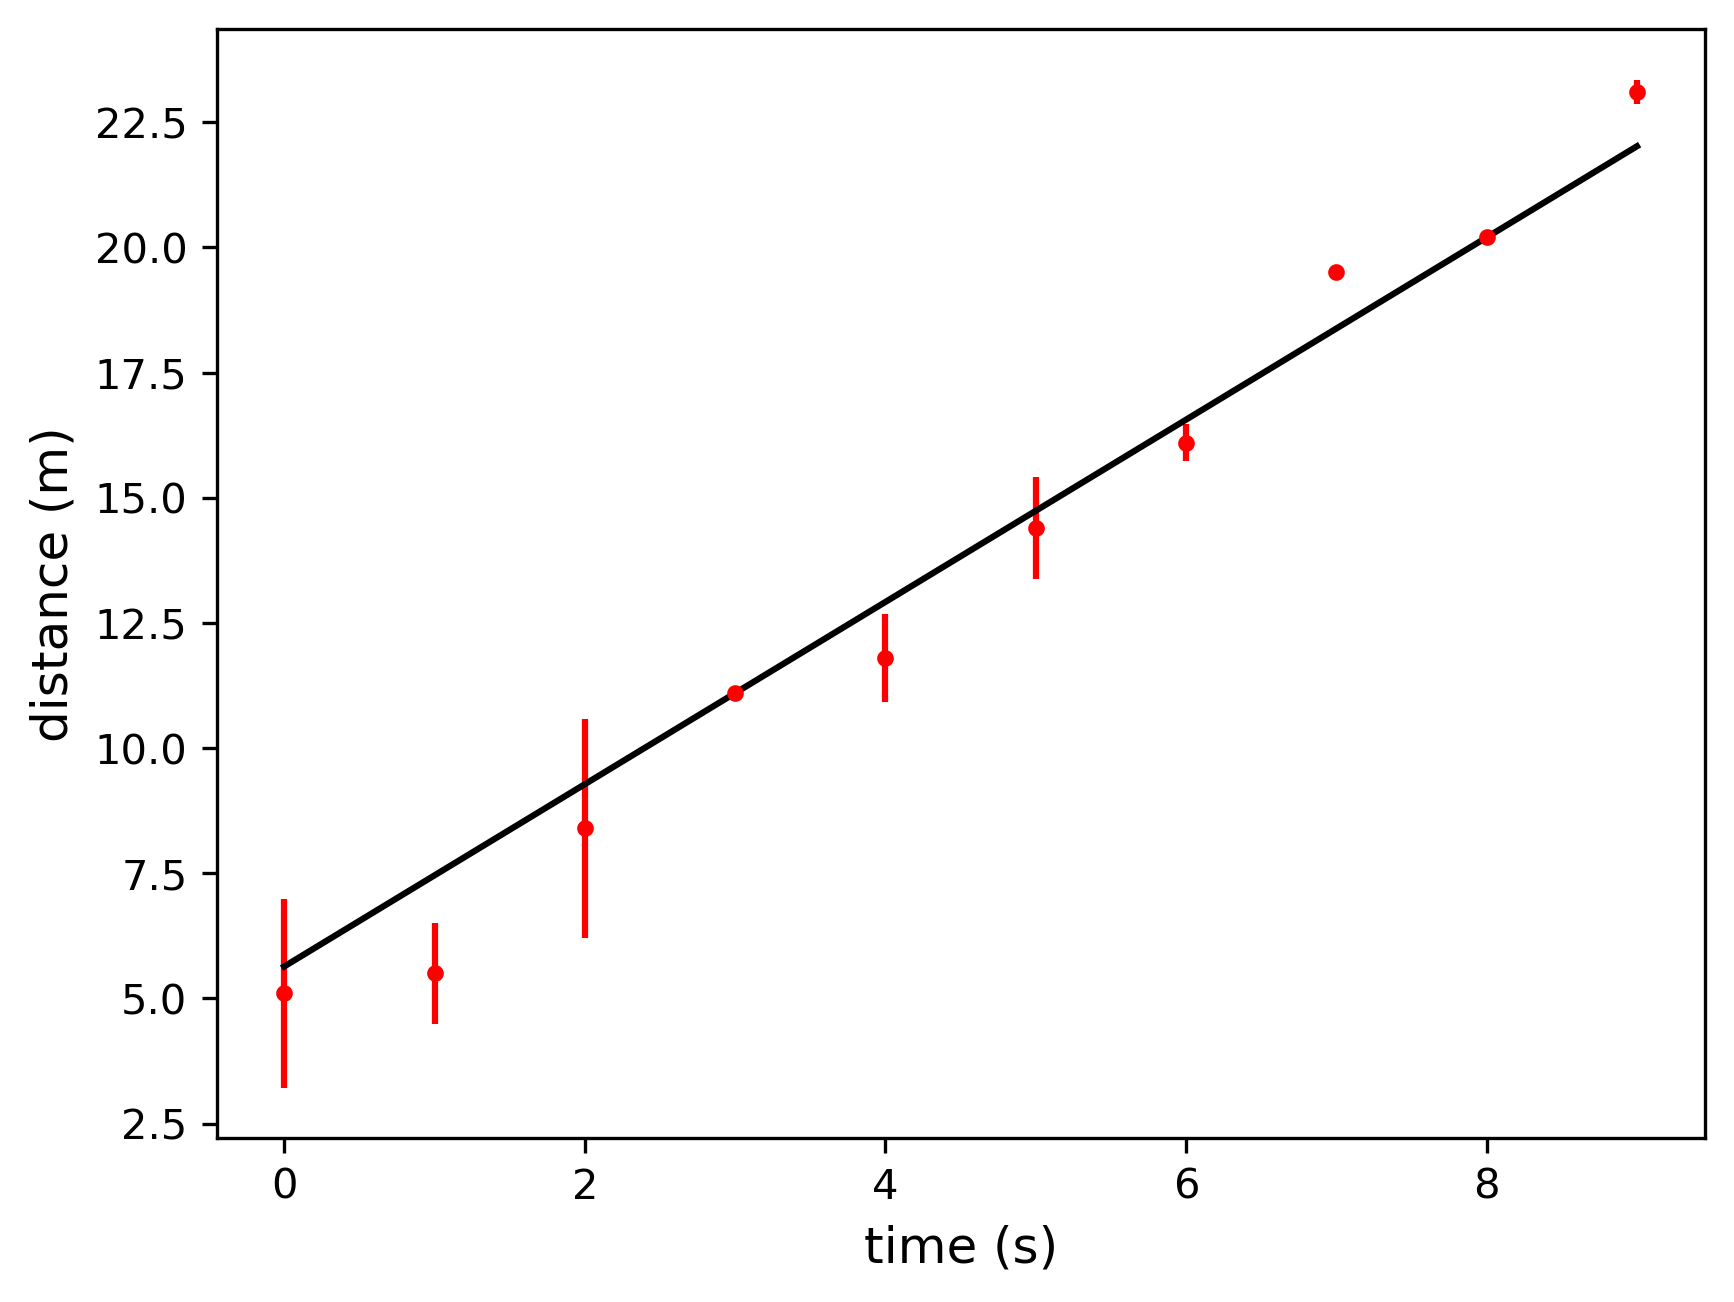

In [25]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'black') #agregue sus parámetros

Comparemos ambos modelos

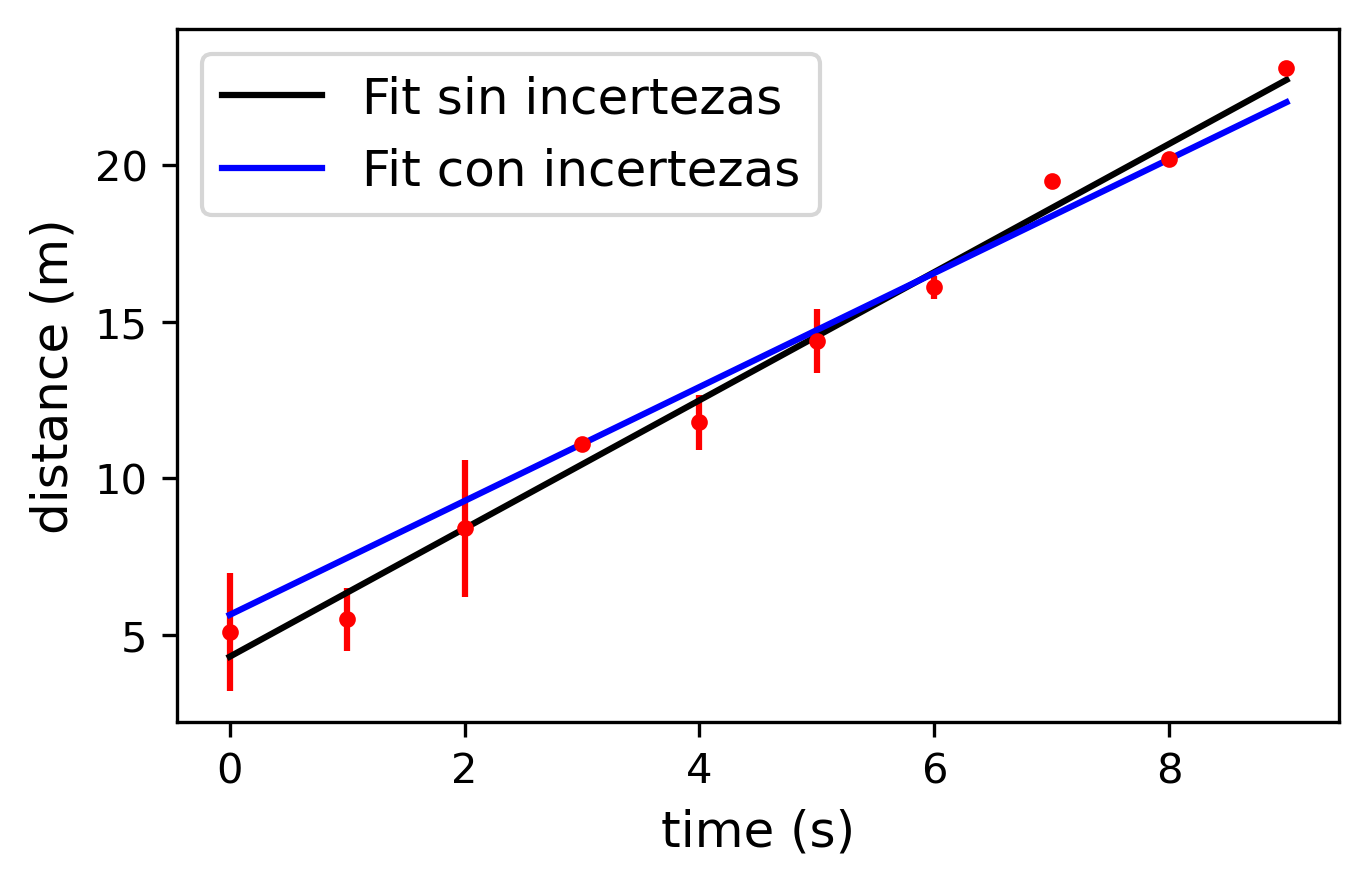

In [26]:
plt.figure(figsize=(5,3))

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')

plt.plot(x, bestb + bestm * x, c = 'black', label = 'Fit sin incertezas')

plt.plot(x, bestb_werr + bestm_werr * x, c = 'b', label = 'Fit con incertezas')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend()


**Pregunta: ¿Tiene sentido ese cambio?**

In [ ]:
#Sí, el cambio tiene sentido. La recta azul toma en cuenta la importancia de cada dato según su nivel de precisión, 
# es decir, prioriza los puntos con barras de error pequeñas por su mayor certeza, permitiendo desviaciones en 
# los puntos cuya incerteza es superior. Mientras el ajuste sin incertezas le da el mismo peso a todas las observaciones.

### Parte 2: Machine Learning

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

#### Importamos de la librería Sci-kit learn los modelos ya implementados y usaremos funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook

In [29]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.6 MB/s  0:00:00 eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]


In [30]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión

In [31]:
from sklearn.linear_model import LinearRegression #modelo de regresión lineal

In [32]:
from sklearn.model_selection import train_test_split  #para dividir los datos

In [33]:
np.random.seed(10) #semilla fija para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #crea los sets de entrenamiento/prueba

In [34]:
X_train, y_train #7 datos de entrenamiento

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [35]:
X_test # 3 de prueba

array([8, 2, 5])

In [36]:
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params

In [37]:
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params default params

construimos el modelo con los datos de entrenamiento y los usamos para predecir el output en los datos de prueba

In [38]:
#predicciones de datos usando árbol de decisión
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [39]:
#predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [40]:
print(y_test, y_pred_reg, y_pred_tree) #Real/predicho por RL y AD respectivamente

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Usaremos como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo

In [41]:
np.mean((y_test-y_pred_reg)**2)

np.float64(0.18201586721857252)

In [42]:
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

In [45]:
#El modelo RL es mejor que el AD, ya que presenta un Error Cuadrático Medio mucho menor, 
# reflejando predicciones notoriamente más precisas en los datos de prueba. Además, la regresión lineal 
# es capaz de capturar la tendencia y extrapolar el resultado para t = 12s,
# mientras que el árbol de decisión es incapaz de predecir valores fuera del rango observado en el entrenamiento.

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [46]:
print(treemodel.predict(np.array(12).reshape(-1, 1)))
print(regmodel.predict(np.array(12).reshape(-1, 1)))

[23.1]
[29.20810811]


In [47]:
#Esto confirma exactamente lo esperado de que el Árbol de Decisión falla al predecir a los 12 segundos 
# porque no puede extrapolar y simplemente asignó el valor máximo que vio durante su entrenamiento.
#En cambio, la Regresión Lineal proyecta correctamente la tendencia, entregando un valor continuo razonable.

### Conclusión

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?
- En el caso de ML, cómo elegimos el mejor modelo?


**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.

In [ ]:
#La inferencia estadística funcionó mejor porque aprovechó el conocimiento físico previo para estimar parámetros interpretables 
# con toda la muestra de datos. Machine Learning despreció datos al dividirlos en el entrenamiento y puede fallar al extrapolar, 
# como ocurrió con el Árbol de Decisión.

In [ ]:
#No habría funcionado bien, ya que si hubieramos usado por ejemplo una función sinusoidal con datos que siguen una tendencia lineal, 
# los parámetros ajustados no tendrán sentido físico y las predicciones futuras serían incorrectas. 

In [ ]:
#Se elige mediante validación cruzada o evaluando métricas de error sobre el conjunto de prueba. 
# Además, se deben considerar las capacidades estructurales del modelo.